In [1]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [9]:
# =========================
#  Load Dataset
# =========================
df = pd.read_excel("School data.xlsx")
print("data load successfull",df)

data load successfull      School_ID    District     Block Urban_Rural  %_Math_Score  \
0        SCH_1  District_C  Block_C1       Rural         43.32   
1        SCH_2  District_A  Block_A3       Rural         81.98   
2        SCH_3  District_B  Block_B1       Rural         44.68   
3        SCH_4  District_A  Block_A1       Urban         44.86   
4        SCH_5  District_C  Block_C1       Rural         47.41   
...        ...         ...       ...         ...           ...   
5195  SCH_5196  District_A  Block_A3       Rural           NaN   
5196  SCH_5197  District_A  Block_A1       Urban         64.93   
5197  SCH_5198  District_B  Block_B1       Rural         67.46   
5198  SCH_5199  District_C  Block_C2       Urban         58.35   
5199  SCH_5200  District_C  Block_C2       Urban         38.73   

      %_Language_Score  %_Science_Score  Teacher_Student_Ratio  \
0                48.87            48.89                   40.1   
1                83.18            83.26              

In [11]:
# =========================
# Data Understanding
# =========================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
print(df.info())
print("\nSummary:\n", df.describe())

Shape: (5200, 17)

Columns:
 Index(['School_ID', 'District', 'Block', 'Urban_Rural', '%_Math_Score',
       '%_Language_Score', '%_Science_Score', 'Teacher_Student_Ratio',
       'Avg_Teacher_Experience_Years', 'Teacher_Trainings_Attended',
       'Electricity_Available', 'Internet_Available', 'Functional_Toilets',
       'Library_Available', '%_Marginalized_Students',
       '%_Students_With_Home_Internet', 'Parent_Literacy_Rate'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %

In [13]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nAfter Cleaning Shape:", df.shape)



Missing Values:
 School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

After Cleaning Shape: (5200, 17)


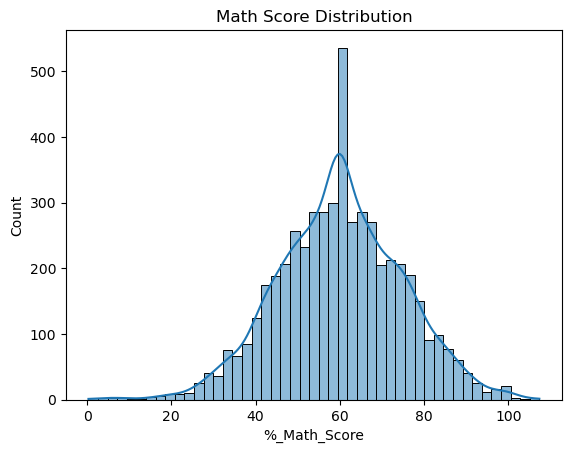

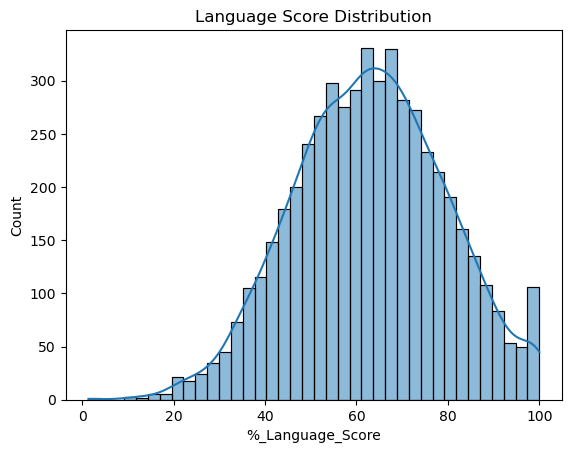

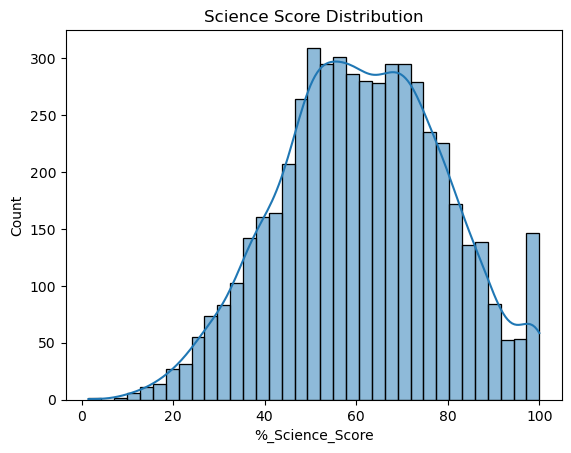

In [15]:
# =========================
# Univariate Analysis
# =========================

# Math Score Distribution
sns.histplot(df['%_Math_Score'], kde=True)
plt.title("Math Score Distribution")
plt.show()

# Language Score
sns.histplot(df['%_Language_Score'], kde=True)
plt.title("Language Score Distribution")
plt.show()

# Science Score
sns.histplot(df['%_Science_Score'], kde=True)
plt.title("Science Score Distribution")
plt.show()

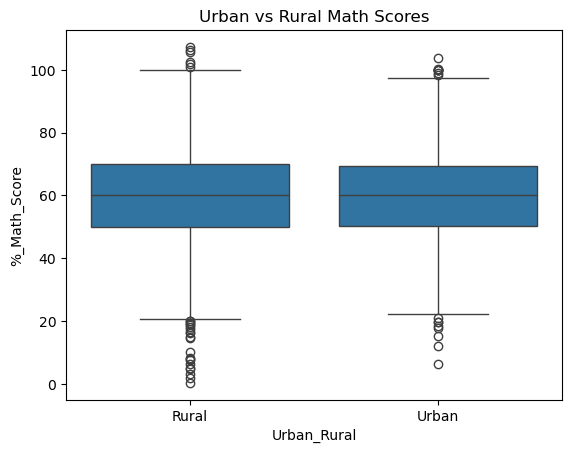

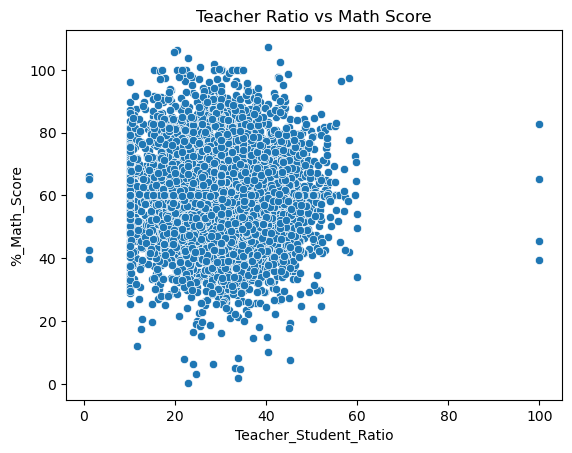

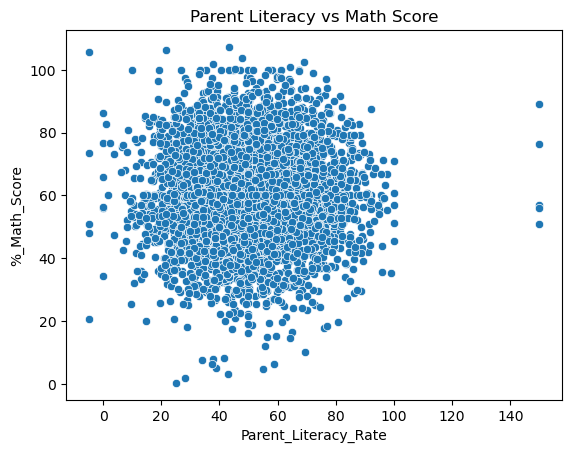

In [17]:
# =========================
#  Bivariate Analysis
# =========================

# Urban vs Math Score
sns.boxplot(x='Urban_Rural', y='%_Math_Score', data=df)
plt.title("Urban vs Rural Math Scores")
plt.show()

# Teacher Student Ratio vs Math Score
sns.scatterplot(x='Teacher_Student_Ratio', y='%_Math_Score', data=df)
plt.title("Teacher Ratio vs Math Score")
plt.show()

# Parent Literacy vs Math Score
sns.scatterplot(x='Parent_Literacy_Rate', y='%_Math_Score', data=df)
plt.title("Parent Literacy vs Math Score")
plt.show()

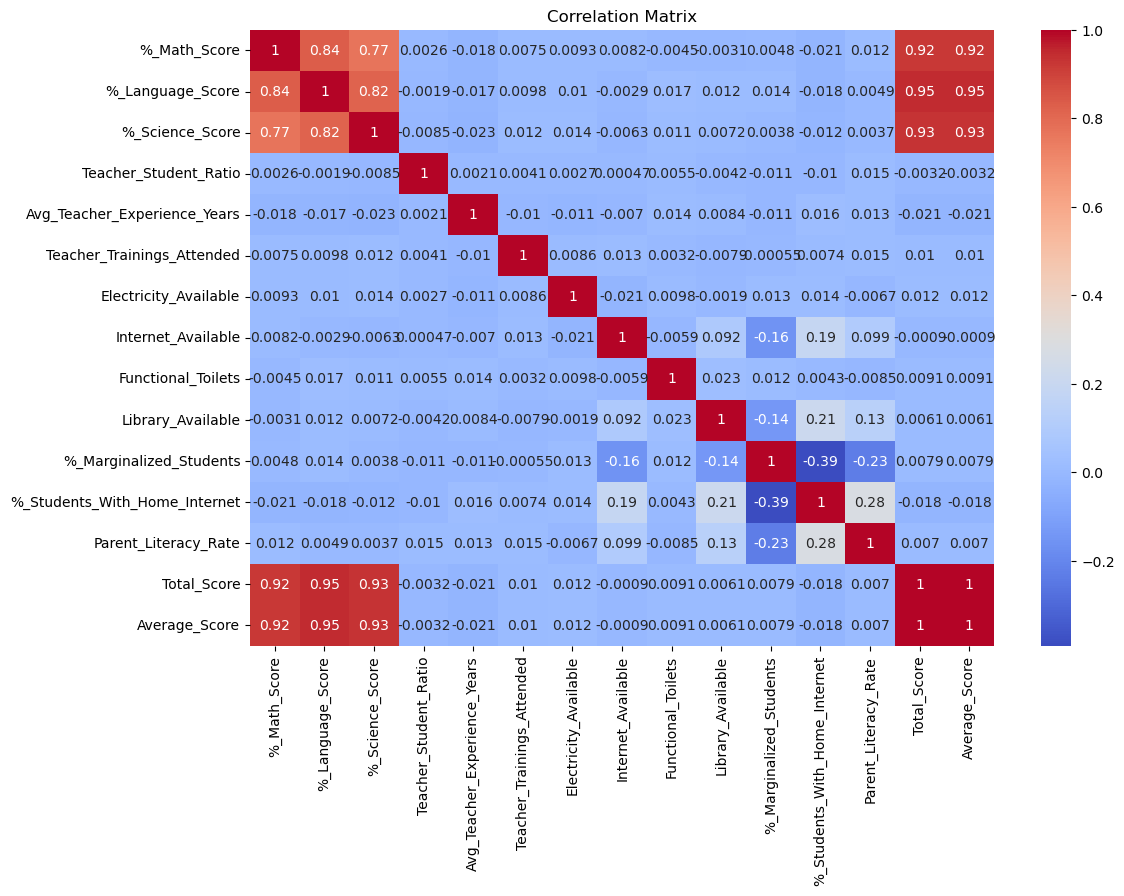

In [23]:
# =========================
#  Correlation Analysis
# =========================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [25]:
# =========================
#  Basic Model 
# =========================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['%_Language_Score', '%_Science_Score', 'Teacher_Student_Ratio', 'Parent_Literacy_Rate']]
y = df['%_Math_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Accuracy:", model.score(X_test, y_test))


Model Accuracy: 0.7569015949903524


In [27]:
# =========================
#  Insights 
# =========================

print("\n--- Insights ---")
print("1. Higher parent literacy tends to increase student performance.")
print("2. Lower teacher-student ratio improves scores.")
print("3. Urban schools often perform better than rural schools.")
print("4. Strong correlation between language and science scores.")
print("5. Infrastructure like internet availability impacts performance.")


--- Insights ---
1. Higher parent literacy tends to increase student performance.
2. Lower teacher-student ratio improves scores.
3. Urban schools often perform better than rural schools.
4. Strong correlation between language and science scores.
5. Infrastructure like internet availability impacts performance.
